# HW07: Clustering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import json

## Dataset 1: S07-hw-dataset-01.csv

In [2]:
df1 = pd.read_csv('data/S07-hw-dataset-01.csv')
df1.head()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
0,0,-0.536647,-69.812900,-0.002657,71.743147,-11.396498,-12.291287,-6.836847,-0.504094
1,1,15.230731,52.727216,-1.273634,-104.123302,11.589643,34.316967,-49.468873,0.390356
2,2,18.542693,77.317150,-1.321686,-111.946636,10.254346,25.892951,44.595250,0.325893
3,3,-12.538905,-41.709458,0.146474,16.322124,1.391137,2.014316,-39.930582,0.139297
4,4,-6.903056,61.833444,-0.022466,-42.631335,3.107154,-5.471054,7.001149,0.131213


In [3]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  float64
 4   f04        12000 non-null  float64
 5   f05        12000 non-null  float64
 6   f06        12000 non-null  float64
 7   f07        12000 non-null  float64
 8   f08        12000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [4]:
df1.describe()

,sample_id,f01,f02,f03,f04,f05,f06,f07,f08
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,5999.50000,-2.424716,19.107804,-0.222063,-8.284501,-0.190717,0.962972,0.033724,0.007638
std,3464.24595,11.014315,60.790338,0.500630,59.269838,7.026435,14.794713,59.541782,0.607053
min,0.00000,-19.912573,-92.892652,-1.590979,-134.303679,-11.869169,-20.521164,-215.098834,-2.633469
25%,2999.75000,-9.472623,-40.282955,-0.125145,-48.345007,-5.132473,-8.807706,-39.900520,-0.401483
50%,5999.50000,-6.869404,54.069335,-0.031753,16.211728,0.444730,-6.134169,-0.578494,0.005306
75%,8999.25000,0.523841,70.280739,0.054980,28.067178,3.942368,2.334426,39.719821,0.410132
max,11999.00000,24.403381,112.229523,0.512277,75.088604,13.717091,41.452857,213.381767,2.490745


In [5]:
X1 = df1.drop('sample_id', axis=1)
preprocessor1 = Pipeline([
    ('scaler', StandardScaler())
])

### KMeans

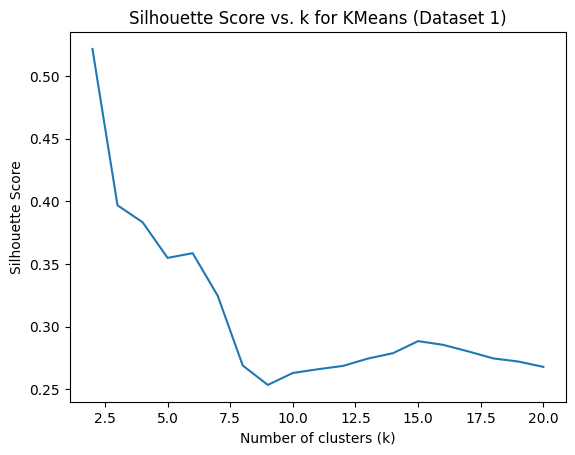

Best k for KMeans (Dataset 1): 2


In [6]:
kmeans_pipeline1 = Pipeline([
    ('preprocessor', preprocessor1),
    ('cluster', KMeans(random_state=42, n_init=10))
])

k_range = range(2, 21)
silhouette_scores1 = []
for k in k_range:
    kmeans_pipeline1.set_params(cluster__n_clusters=k)
    kmeans_pipeline1.fit(X1)
    labels = kmeans_pipeline1.named_steps['cluster'].labels_
    silhouette_scores1.append(silhouette_score(kmeans_pipeline1.named_steps['preprocessor'].transform(X1), labels))

plt.plot(k_range, silhouette_scores1)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for KMeans (Dataset 1)')
plt.savefig('artifacts/figures/silhouette_vs_k_kmeans_dataset1.png')
plt.show()

best_k1 = k_range[np.argmax(silhouette_scores1)]
print(f'Best k for KMeans (Dataset 1): {best_k1}')

### Agglomerative Clustering

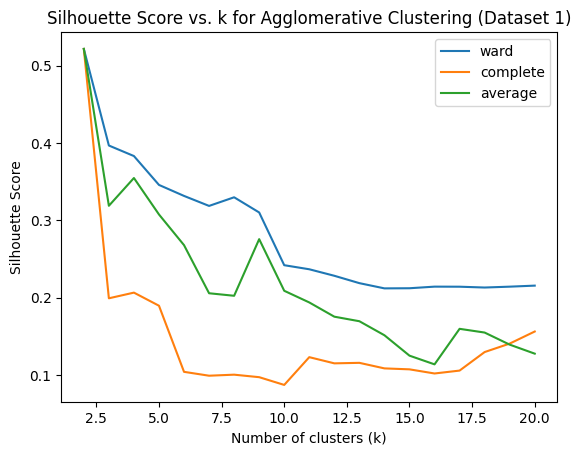

Best params for Agglomerative Clustering (Dataset 1): {'n_clusters': 2, 'linkage': 'ward'}


In [7]:
agg_pipeline1 = Pipeline([
    ('preprocessor', preprocessor1),
    ('cluster', AgglomerativeClustering())
])

linkage_options = ['ward', 'complete', 'average']
best_score_agg1 = -1
best_params_agg1 = {}

for linkage in linkage_options:
    silhouette_scores_agg = []
    for k in k_range:
        agg_pipeline1.set_params(cluster__n_clusters=k, cluster__linkage=linkage)
        agg_pipeline1.fit(X1)
        labels = agg_pipeline1.named_steps['cluster'].labels_
        score = silhouette_score(agg_pipeline1.named_steps['preprocessor'].transform(X1), labels)
        silhouette_scores_agg.append(score)
        if score > best_score_agg1:
            best_score_agg1 = score
            best_params_agg1 = {'n_clusters': k, 'linkage': linkage}
    plt.plot(k_range, silhouette_scores_agg, label=linkage)

plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for Agglomerative Clustering (Dataset 1)')
plt.legend()
plt.savefig('artifacts/figures/silhouette_vs_k_agg_dataset1.png')
plt.show()

print(f'Best params for Agglomerative Clustering (Dataset 1): {best_params_agg1}')

### Evaluation

In [8]:
kmeans_pipeline1.set_params(cluster__n_clusters=best_k1)
kmeans_pipeline1.fit(X1)
kmeans_labels1 = kmeans_pipeline1.named_steps['cluster'].labels_
X1_scaled = kmeans_pipeline1.named_steps['preprocessor'].transform(X1)

agg_pipeline1.set_params(cluster__n_clusters=best_params_agg1['n_clusters'], cluster__linkage=best_params_agg1['linkage'])
agg_pipeline1.fit(X1)
agg_labels1 = agg_pipeline1.named_steps['cluster'].labels_

metrics1 = {
    'KMeans': {
        'silhouette': silhouette_score(X1_scaled, kmeans_labels1),
        'davies_bouldin': davies_bouldin_score(X1_scaled, kmeans_labels1),
        'calinski_harabasz': calinski_harabasz_score(X1_scaled, kmeans_labels1)
    },
    'Agglomerative': {
        'silhouette': silhouette_score(X1_scaled, agg_labels1),
        'davies_bouldin': davies_bouldin_score(X1_scaled, agg_labels1),
        'calinski_harabasz': calinski_harabasz_score(X1_scaled, agg_labels1)
    }
}

print(json.dumps(metrics1, indent=4))

{
    "KMeans": {
        "silhouette": 0.5216395622404242,
        "davies_bouldin": 0.6853295219054459,
        "calinski_harabasz": 11786.95462267153
    },
    "Agglomerative": {
        "silhouette": 0.5216395622404242,
        "davies_bouldin": 0.6853295219054459,
        "calinski_harabasz": 11786.95462267153
    }
}


### Visualization

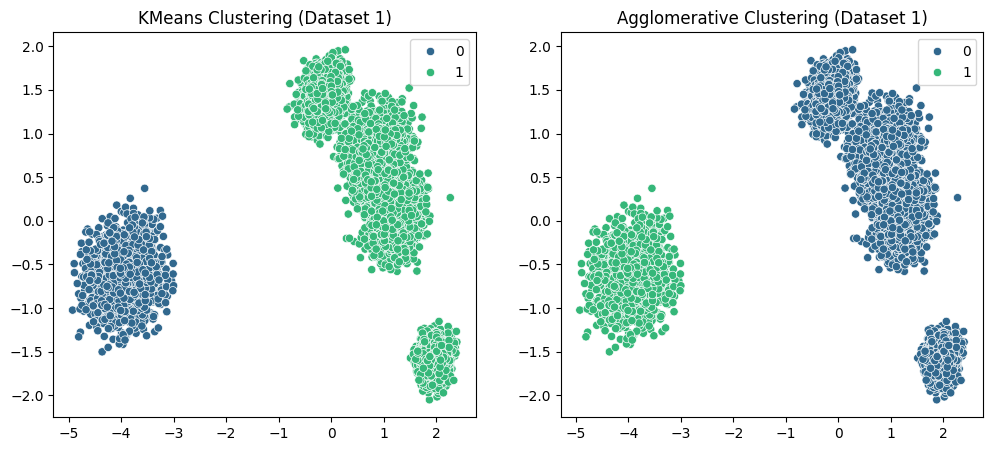

In [9]:
pca = PCA(n_components=2, random_state=42)
X1_pca = pca.fit_transform(X1_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X1_pca[:, 0], y=X1_pca[:, 1], hue=kmeans_labels1, palette='viridis')
plt.title('KMeans Clustering (Dataset 1)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X1_pca[:, 0], y=X1_pca[:, 1], hue=agg_labels1, palette='viridis')
plt.title('Agglomerative Clustering (Dataset 1)')
plt.savefig('artifacts/figures/pca_dataset1.png')
plt.show()

### Stability Check (Dataset 1)

In [10]:
ari_scores1 = []
prev_labels = None
for i in range(5):
    kmeans_pipeline1.set_params(cluster__n_clusters=best_k1, cluster__random_state=i)
    kmeans_pipeline1.fit(X1)
    labels = kmeans_pipeline1.named_steps['cluster'].labels_
    if i > 0:
        ari_scores1.append(adjusted_rand_score(prev_labels, labels))
    prev_labels = labels
print(f'ARI scores for 5 runs (Dataset 1): {ari_scores1}')

ARI scores for 5 runs (Dataset 1): [1.0, 1.0, 1.0, 1.0]


## Dataset 2: S07-hw-dataset-02.csv

In [11]:
df2 = pd.read_csv('data/S07-hw-dataset-02.csv')
X2 = df2.drop('sample_id', axis=1)
preprocessor2 = Pipeline([
    ('scaler', StandardScaler())
])

### KMeans

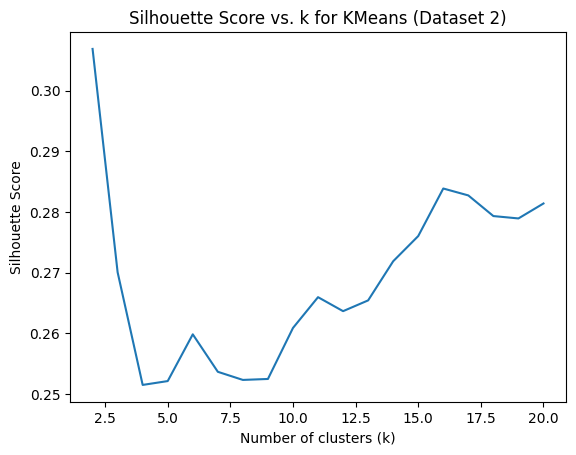

Best k for KMeans (Dataset 2): 2


In [12]:
kmeans_pipeline2 = Pipeline([
    ('preprocessor', preprocessor2),
    ('cluster', KMeans(random_state=42, n_init=10))
])

k_range = range(2, 21)
silhouette_scores2 = []
for k in k_range:
    kmeans_pipeline2.set_params(cluster__n_clusters=k)
    kmeans_pipeline2.fit(X2)
    labels = kmeans_pipeline2.named_steps['cluster'].labels_
    silhouette_scores2.append(silhouette_score(kmeans_pipeline2.named_steps['preprocessor'].transform(X2), labels))

plt.plot(k_range, silhouette_scores2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for KMeans (Dataset 2)')
plt.savefig('artifacts/figures/silhouette_vs_k_kmeans_dataset2.png')
plt.show()

best_k2 = k_range[np.argmax(silhouette_scores2)]
print(f'Best k for KMeans (Dataset 2): {best_k2}')

### DBSCAN

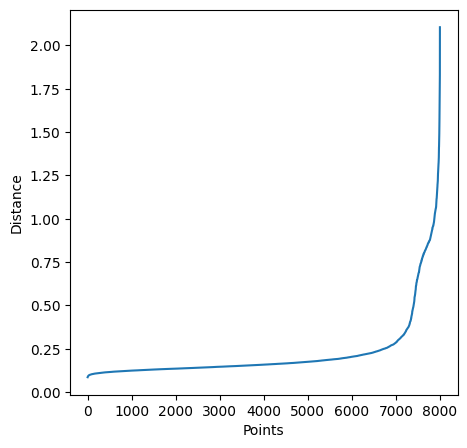

In [13]:
X2_scaled = preprocessor2.fit_transform(X2)
nearest_neighbors = NearestNeighbors(n_neighbors=11)
neighbors = nearest_neighbors.fit(X2_scaled)
distances, indices = neighbors.kneighbors(X2_scaled)
distances = np.sort(distances[:,10], axis=0)
fig = plt.figure(figsize=(5, 5))
plt.plot(distances)
plt.xlabel('Points')
plt.ylabel('Distance')
plt.savefig('artifacts/figures/k_distance_plot_dataset2.png')
plt.show()


In [14]:
dbscan_pipeline2 = Pipeline([
    ('preprocessor', preprocessor2),
    ('cluster', DBSCAN())
])

eps_range = np.arange(0.1, 1.0, 0.1)
min_samples_range = range(2, 11)
best_score_dbscan2 = -1
best_params_dbscan2 = {}

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan_pipeline2.set_params(cluster__eps=eps, cluster__min_samples=min_samples)
        dbscan_pipeline2.fit(X2)
        labels = dbscan_pipeline2.named_steps['cluster'].labels_
        noise_mask = labels != -1
        if len(np.unique(labels[noise_mask])) > 1:
            X2_scaled = dbscan_pipeline2.named_steps['preprocessor'].transform(X2)
            score = silhouette_score(X2_scaled[noise_mask], labels[noise_mask])
            if score > best_score_dbscan2:
                best_score_dbscan2 = score
                best_params_dbscan2 = {'eps': eps, 'min_samples': min_samples}

print(f'Best params for DBSCAN (Dataset 2): {best_params_dbscan2}')

Best params for DBSCAN (Dataset 2): {'eps': np.float64(0.1), 'min_samples': 10}


### Evaluation

In [15]:
kmeans_pipeline2.set_params(cluster__n_clusters=best_k2)
kmeans_pipeline2.fit(X2)
kmeans_labels2 = kmeans_pipeline2.named_steps['cluster'].labels_
X2_scaled = kmeans_pipeline2.named_steps['preprocessor'].transform(X2)

dbscan_pipeline2.set_params(cluster__eps=best_params_dbscan2['eps'], cluster__min_samples=best_params_dbscan2['min_samples'])
dbscan_pipeline2.fit(X2)
dbscan_labels2 = dbscan_pipeline2.named_steps['cluster'].labels_

metrics2 = {
    'KMeans': {
        'silhouette': silhouette_score(X2_scaled, kmeans_labels2),
        'davies_bouldin': davies_bouldin_score(X2_scaled, kmeans_labels2),
        'calinski_harabasz': calinski_harabasz_score(X2_scaled, kmeans_labels2)
    }
}

noise_mask2 = dbscan_labels2 != -1
if np.sum(noise_mask2) > 1 and len(np.unique(dbscan_labels2[noise_mask2])) > 1:
    metrics2['DBSCAN'] = {
        'silhouette': silhouette_score(X2_scaled[noise_mask2], dbscan_labels2[noise_mask2]),
        'davies_bouldin': davies_bouldin_score(X2_scaled[noise_mask2], dbscan_labels2[noise_mask2]),
        'calinski_harabasz': calinski_harabasz_score(X2_scaled[noise_mask2], dbscan_labels2[noise_mask2]),
        'noise': np.sum(dbscan_labels2 == -1) / len(dbscan_labels2)
    }

print(json.dumps(metrics2, indent=4))

{
    "KMeans": {
        "silhouette": 0.3068610017701601,
        "davies_bouldin": 1.3234721699867644,
        "calinski_harabasz": 3573.3933329348392
    },
    "DBSCAN": {
        "silhouette": 0.5812458584406734,
        "davies_bouldin": 0.5779820069800069,
        "calinski_harabasz": 2758.1225203015906,
        "noise": 0.9185
    }
}


### Visualization

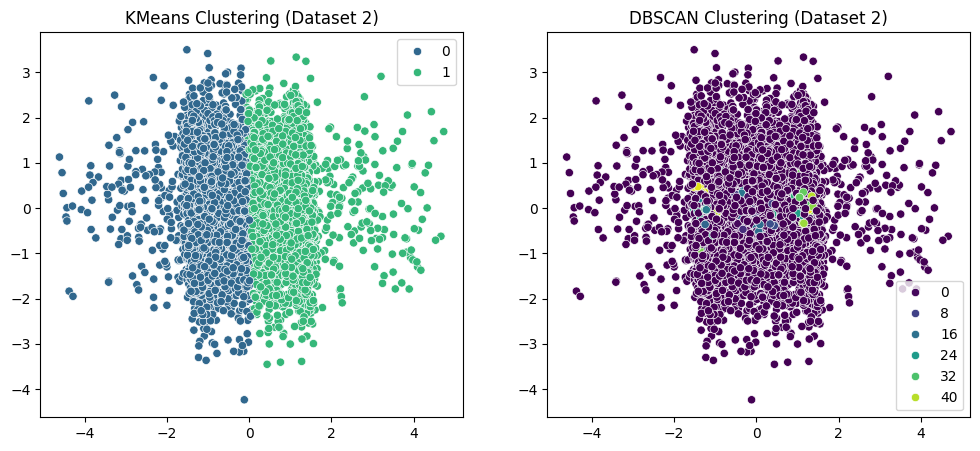

In [16]:
pca = PCA(n_components=2, random_state=42)
X2_pca = pca.fit_transform(X2_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X2_pca[:, 0], y=X2_pca[:, 1], hue=kmeans_labels2, palette='viridis')
plt.title('KMeans Clustering (Dataset 2)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X2_pca[:, 0], y=X2_pca[:, 1], hue=dbscan_labels2, palette='viridis')
plt.title('DBSCAN Clustering (Dataset 2)')
plt.savefig('artifacts/figures/pca_dataset2.png')
plt.show()

## Dataset 3: S07-hw-dataset-03.csv

In [17]:
df3 = pd.read_csv('data/S07-hw-dataset-03.csv')
X3 = df3.drop('sample_id', axis=1)
preprocessor3 = Pipeline([
    ('scaler', StandardScaler())
])

### KMeans

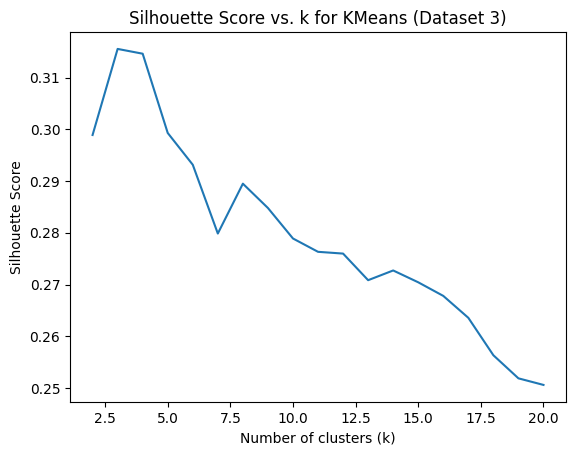

Best k for KMeans (Dataset 3): 3


In [18]:
kmeans_pipeline3 = Pipeline([
    ('preprocessor', preprocessor3),
    ('cluster', KMeans(random_state=42, n_init=10))
])

k_range = range(2, 21)
silhouette_scores3 = []
for k in k_range:
    kmeans_pipeline3.set_params(cluster__n_clusters=k)
    kmeans_pipeline3.fit(X3)
    labels = kmeans_pipeline3.named_steps['cluster'].labels_
    silhouette_scores3.append(silhouette_score(kmeans_pipeline3.named_steps['preprocessor'].transform(X3), labels))

plt.plot(k_range, silhouette_scores3)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k for KMeans (Dataset 3)')
plt.savefig('artifacts/figures/silhouette_vs_k_kmeans_dataset3.png')
plt.show()

best_k3 = k_range[np.argmax(silhouette_scores3)]
print(f'Best k for KMeans (Dataset 3): {best_k3}')

### DBSCAN

In [19]:
dbscan_pipeline3 = Pipeline([
    ('preprocessor', preprocessor3),
    ('cluster', DBSCAN())
])

eps_range = np.arange(0.1, 1.0, 0.1)
min_samples_range = range(2, 11)
best_score_dbscan3 = -1
best_params_dbscan3 = {}

for eps in eps_range:
    for min_samples in min_samples_range:
        dbscan_pipeline3.set_params(cluster__eps=eps, cluster__min_samples=min_samples)
        dbscan_pipeline3.fit(X3)
        labels = dbscan_pipeline3.named_steps['cluster'].labels_
        noise_mask = labels != -1
        if len(np.unique(labels[noise_mask])) > 1:
            X3_scaled = dbscan_pipeline3.named_steps['preprocessor'].transform(X3)
            score = silhouette_score(X3_scaled[noise_mask], labels[noise_mask])
            if score > best_score_dbscan3:
                best_score_dbscan3 = score
                best_params_dbscan3 = {'eps': eps, 'min_samples': min_samples}

print(f'Best params for DBSCAN (Dataset 3): {best_params_dbscan3}')

Best params for DBSCAN (Dataset 3): {'eps': np.float64(0.1), 'min_samples': 10}


### Evaluation

In [20]:
kmeans_pipeline3.set_params(cluster__n_clusters=best_k3)
kmeans_pipeline3.fit(X3)
kmeans_labels3 = kmeans_pipeline3.named_steps['cluster'].labels_
X3_scaled = kmeans_pipeline3.named_steps['preprocessor'].transform(X3)

dbscan_pipeline3.set_params(cluster__eps=best_params_dbscan3['eps'], cluster__min_samples=best_params_dbscan3['min_samples'])
dbscan_pipeline3.fit(X3)
dbscan_labels3 = dbscan_pipeline3.named_steps['cluster'].labels_

metrics3 = {
    'KMeans': {
        'silhouette': silhouette_score(X3_scaled, kmeans_labels3),
        'davies_bouldin': davies_bouldin_score(X3_scaled, kmeans_labels3),
        'calinski_harabasz': calinski_harabasz_score(X3_scaled, kmeans_labels3)
    }
}

noise_mask3 = dbscan_labels3 != -1
if np.sum(noise_mask3) > 1 and len(np.unique(dbscan_labels3[noise_mask3])) > 1:
    metrics3['DBSCAN'] = {
        'silhouette': silhouette_score(X3_scaled[noise_mask3], dbscan_labels3[noise_mask3]),
        'davies_bouldin': davies_bouldin_score(X3_scaled[noise_mask3], dbscan_labels3[noise_mask3]),
        'calinski_harabasz': calinski_harabasz_score(X3_scaled[noise_mask3], dbscan_labels3[noise_mask3]),
        'noise': np.sum(dbscan_labels3 == -1) / len(dbscan_labels3)
    }

print(json.dumps(metrics3, indent=4))

{
    "KMeans": {
        "silhouette": 0.31554470037825183,
        "davies_bouldin": 1.1577256320598661,
        "calinski_harabasz": 6957.162639510166
    },
    "DBSCAN": {
        "silhouette": 0.812135611234154,
        "davies_bouldin": 0.2449468669104906,
        "calinski_harabasz": 3564.021041770511,
        "noise": 0.9959333333333333
    }
}


### Visualization

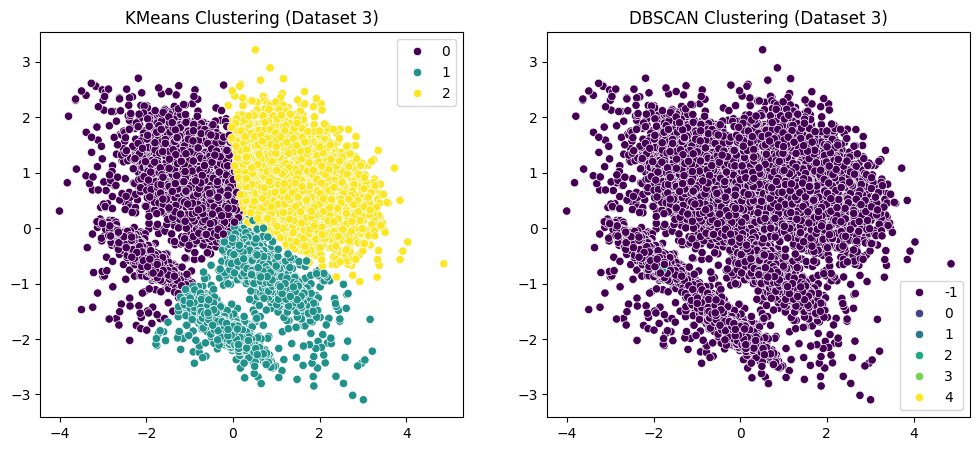

In [21]:
pca = PCA(n_components=2, random_state=42)
X3_pca = pca.fit_transform(X3_scaled)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(x=X3_pca[:, 0], y=X3_pca[:, 1], hue=kmeans_labels3, palette='viridis')
plt.title('KMeans Clustering (Dataset 3)')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X3_pca[:, 0], y=X3_pca[:, 1], hue=dbscan_labels3, palette='viridis')
plt.title('DBSCAN Clustering (Dataset 3)')
plt.savefig('artifacts/figures/pca_dataset3.png')
plt.show()

## Save Artifacts

In [22]:
metrics_summary = {
    'dataset1': metrics1,
    'dataset2': metrics2,
    'dataset3': metrics3
}

with open('artifacts/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f, indent=4)

best_configs = {
    'dataset1': {
        'KMeans': {'k': best_k1},
        'Agglomerative': best_params_agg1,
        'best_model': max(metrics1, key=lambda model: metrics1[model]['silhouette'])
    },
    'dataset2': {
        'KMeans': {'k': best_k2},
        'DBSCAN': best_params_dbscan2,
        'best_model': max(metrics2, key=lambda model: metrics2[model]['silhouette'])
    },
    'dataset3': {
        'KMeans': {'k': best_k3},
        'DBSCAN': best_params_dbscan3,
        'best_model': max(metrics3, key=lambda model: metrics3[model]['silhouette'])
    }
}

with open('artifacts/best_configs.json', 'w') as f:
    json.dump(best_configs, f, indent=4)

best_model1_name = best_configs['dataset1']['best_model']
if best_model1_name == 'KMeans':
    labels1 = kmeans_labels1
else:
    labels1 = agg_labels1

labels1_df = pd.DataFrame({'sample_id': df1['sample_id'], 'cluster_label': labels1})
labels1_df.to_csv('artifacts/labels/labels_hw07_ds1.csv', index=False)

best_model2_name = best_configs['dataset2']['best_model']
if best_model2_name == 'KMeans':
    labels2 = kmeans_labels2
else:
    labels2 = dbscan_labels2
    
labels2_df = pd.DataFrame({'sample_id': df2['sample_id'], 'cluster_label': labels2})
labels2_df.to_csv('artifacts/labels/labels_hw07_ds2.csv', index=False)

best_model3_name = best_configs['dataset3']['best_model']
if best_model3_name == 'KMeans':
    labels3 = kmeans_labels3
else:
    labels3 = dbscan_labels3

labels3_df = pd.DataFrame({'sample_id': df3['sample_id'], 'cluster_label': labels3})
labels3_df.to_csv('artifacts/labels/labels_hw07_ds3.csv', index=False)